In [1]:
!pip install -q datasets transformers accelerate evaluate
!pip install -q nltk gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.3 MB/s eta 0:00:00


In [2]:
import re
import string
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from datasets import load_dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout,
    Input,
    GlobalMaxPooling1D,
    SpatialDropout1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [3]:
dataset = load_dataset("google-research-datasets/go_emotions")

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.77MB            

simplified/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

simplified/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  350kB            

simplified/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

simplified/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  347kB            

simplified/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [4]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (43410, 3)
Validation: (5426, 3)
Test: (5427, 3)


In [5]:
train_df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    43410 non-null  object
 1   labels  43410 non-null  object
 2   id      43410 non-null  object
dtypes: object(3)
memory usage: 1017.6+ KB


In [7]:
emotion_names = dataset["train"].features["labels"].feature.names

print(f"Total emotions: {len(emotion_names)}")

for i, emotion in enumerate(emotion_names):
    print(i, emotion)

Total emotions: 28
0 admiration
1 amusement
2 anger
3 annoyance
4 approval
5 caring
6 confusion
7 curiosity
8 desire
9 disappointment
10 disapproval
11 disgust
12 embarrassment
13 excitement
14 fear
15 gratitude
16 grief
17 joy
18 love
19 nervousness
20 optimism
21 pride
22 realization
23 relief
24 remorse
25 sadness
26 surprise
27 neutral


In [8]:
emotion_mapping = {
    "admiration": "joy",
    "amusement": "joy",
    "approval": "joy",
    "caring": "joy",
    "desire": "joy",
    "excitement": "joy",
    "gratitude": "joy",
    "joy": "joy",
    "love": "joy",
    "optimism": "joy",
    "pride": "joy",
    "relief": "joy",

    "anger": "anger",
    "annoyance": "anger",
    "disapproval": "anger",

    "fear": "fear",
    "nervousness": "fear",

    "disgust": "disgust",
    "embarrassment": "disgust",

    "disappointment": "sadness",
    "grief": "sadness",
    "remorse": "sadness",
    "sadness": "sadness",

    "realization": "surprise",
    "surprise": "surprise"
}

In [9]:
emotion_names = dataset["train"].features["labels"].feature.names

def map_labels(labels):
    mapped = []

    for label in labels:
        emotion = emotion_names[label]

        if emotion in emotion_mapping:
            mapped.append(emotion_mapping[emotion])

    mapped = list(set(mapped))

    if len(mapped) == 1:
        return mapped[0]

    return None

In [10]:
for df in [train_df, val_df, test_df]:
    df["emotion"] = df["labels"].apply(map_labels)
    df.dropna(subset=["emotion"], inplace=True)
    df.reset_index(drop=True, inplace=True)

In [11]:
print(train_df.shape)
print(train_df["emotion"].value_counts())

(26060, 4)
emotion
joy         16173
anger        4709
sadness      2288
surprise     1542
disgust       764
fear          584
Name: count, dtype: int64


In [12]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    text = re.sub(r"\s+", " ", text).strip()

    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

In [13]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [14]:
label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["emotion"])
val_df["label"] = label_encoder.transform(val_df["emotion"])
test_df["label"] = label_encoder.transform(test_df["emotion"])

NUM_CLASSES = len(label_encoder.classes_)

print(label_encoder.classes_)

['anger' 'disgust' 'fear' 'joy' 'sadness' 'surprise']


In [15]:
MAX_WORDS = 30000
MAX_LEN = 100

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(train_df["clean_text"])

In [16]:
X_train = tokenizer.texts_to_sequences(train_df["clean_text"])
X_val = tokenizer.texts_to_sequences(val_df["clean_text"])
X_test = tokenizer.texts_to_sequences(test_df["clean_text"])

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post")
X_val = pad_sequences(X_val, maxlen=MAX_LEN, padding="post")
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding="post")

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print(VOCAB_SIZE)
print(X_train.shape)

18335
(26060, 100)


In [17]:
import gensim.downloader as api

fasttext_model = api.load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded


In [18]:
EMBEDDING_DIM = 300

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

hits = 0
misses = 0

for word, idx in tokenizer.word_index.items():

    if idx >= VOCAB_SIZE:
        continue

    try:
        embedding_matrix[idx] = fasttext_model[word]
        hits += 1
    except KeyError:
        misses += 1

print(f"Found: {hits}")
print(f"Missing: {misses}")
print("Embedding Shape:", embedding_matrix.shape)

Found: 14765
Missing: 3569
Embedding Shape: (18335, 300)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True,
        mask_zero=True
    ),

    LSTM(
        128,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

In [20]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     5,500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,500,500 (20.98 MB)

 Trainable params: 5,500,500 (20.98 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2
)

In [22]:
history_lstm = lstm_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=10,

    batch_size=64,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 187s 425ms/step - accuracy: 0.6881 - loss: 0.9357 - val_accuracy: 0.7489 - val_loss: 0.7264 - learning_rate: 0.0010
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 165s 404ms/step - accuracy: 0.8004 - loss: 0.6110 - val_accuracy: 0.7813 - val_loss: 0.6681 - learning_rate: 0.0010
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 165s 404ms/step - accuracy: 0.8627 - loss: 0.4318 - val_accuracy: 0.7660 - val_loss: 0.7109 - learning_rate: 0.0010
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 204s 409ms/step - accuracy: 0.9013 - loss: 0.3103 - val_accuracy: 0.7562 - val_loss: 0.8878 - learning_rate: 0.0010
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 166s 407ms/step - accuracy: 0.9336 - loss: 0.2117 - val_accuracy: 0.7464 - val_loss: 1.0169 - learning_rate: 5.0000e-04


In [23]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred = np.argmax(
    lstm_model.predict(X_test),
    axis=1
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

103/103 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step
Accuracy: 0.7563791008505468
Macro F1: 0.6047760525554094
              precision    recall  f1-score   support

       anger       0.57      0.62      0.60       633
     disgust       0.57      0.41      0.48       109
        fear       0.78      0.55      0.65        85
         joy       0.83      0.91      0.87      1980
     sadness       0.69      0.47      0.56       274
    surprise       0.68      0.36      0.48       211

    accuracy                           0.76      3292
   macro avg       0.69      0.56      0.60      3292
weighted avg       0.75      0.76      0.75      3292



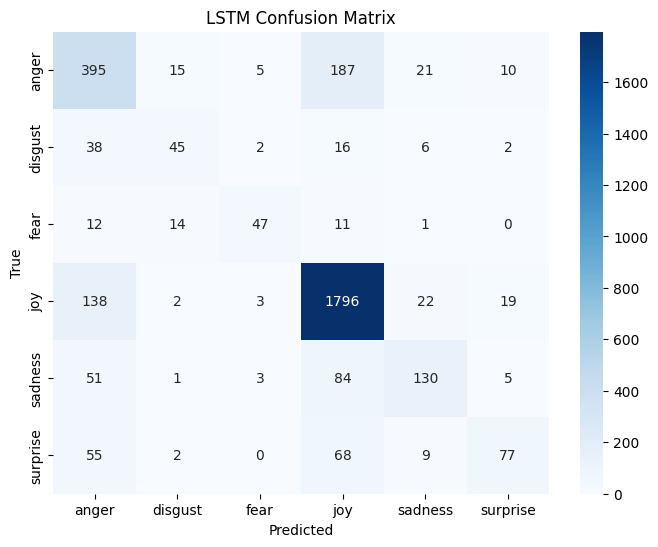

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LSTM Confusion Matrix")
plt.show()

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

gru_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True,
        mask_zero=True
    ),

    GRU(
        128,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    Dense(64, activation="relu"),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     5,500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,500,500 (20.98 MB)

 Trainable params: 5,500,500 (20.98 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history_gru = gru_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=10,

    batch_size=64,

    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 148s 355ms/step - accuracy: 0.6993 - loss: 0.9212 - val_accuracy: 0.7599 - val_loss: 0.7008 - learning_rate: 0.0010
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 144s 354ms/step - accuracy: 0.8078 - loss: 0.5940 - val_accuracy: 0.7822 - val_loss: 0.6406 - learning_rate: 0.0010
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 143s 351ms/step - accuracy: 0.8623 - loss: 0.4217 - val_accuracy: 0.7614 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 143s 350ms/step - accuracy: 0.9019 - loss: 0.3104 - val_accuracy: 0.7522 - val_loss: 0.8514 - learning_rate: 0.0010
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 144s 353ms/step - accuracy: 0.9371 - loss: 0.2061 - val_accuracy: 0.7433 - val_loss: 1.0236 - learning_rate: 5.0000e-04


In [27]:
y_pred = np.argmax(
    gru_model.predict(X_test),
    axis=1
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(y_test, y_pred, average="macro")
)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

103/103 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step
Accuracy: 0.7609356014580801
Macro F1: 0.6092289062960005
              precision    recall  f1-score   support

       anger       0.59      0.62      0.61       633
     disgust       0.67      0.29      0.41       109
        fear       0.84      0.60      0.70        85
         joy       0.83      0.91      0.87      1980
     sadness       0.66      0.55      0.60       274
    surprise       0.70      0.36      0.48       211

    accuracy                           0.76      3292
   macro avg       0.71      0.56      0.61      3292
weighted avg       0.75      0.76      0.75      3292



In [42]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    AdditiveAttention,
    GlobalAveragePooling1D
)

tf.keras.backend.clear_session()

In [43]:
class Attention(Layer):

    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):

        e = K.tanh(K.dot(x, self.W) + self.b)

        a = K.softmax(e, axis=1)

        output = x * a

        return K.sum(output, axis=1)

In [44]:
inputs = Input(shape=(MAX_LEN,), name="input")

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=True
)(inputs)

bilstm = Bidirectional(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)(embedding)

attention = AdditiveAttention()([bilstm, bilstm])

context = GlobalAveragePooling1D()(attention)

x = Dense(64, activation="relu")(context)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

attention_model = Model(inputs, outputs)

In [45]:
attention_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

attention_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 300)  │  5,500,500 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 256)  │    439,296 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention  │ (None, 100, 256)  │        256 │ bidirectional[0]… │
│ (AdditiveAttention) │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ additive_attenti… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │        390 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,956,890 (22.72 MB)

 Trainable params: 5,956,890 (22.72 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history_attention = attention_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 260s 623ms/step - accuracy: 0.6663 - loss: 1.0067 - val_accuracy: 0.7437 - val_loss: 0.7411 - learning_rate: 0.0010
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 254s 622ms/step - accuracy: 0.7936 - loss: 0.6300 - val_accuracy: 0.7856 - val_loss: 0.6481 - learning_rate: 0.0010
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 260s 637ms/step - accuracy: 0.8672 - loss: 0.4315 - val_accuracy: 0.7785 - val_loss: 0.6857 - learning_rate: 5.0000e-04


In [47]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = np.argmax(attention_model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

103/103 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step
Accuracy: 0.7223572296476306
Macro F1: 0.37051659473995935
              precision    recall  f1-score   support

       anger       0.56      0.56      0.56       633
     disgust       0.55      0.06      0.10       109
        fear       0.00      0.00      0.00        85
         joy       0.79      0.94      0.86      1980
     sadness       0.51      0.50      0.50       274
    surprise       0.62      0.12      0.20       211

    accuracy                           0.72      3292
   macro avg       0.51      0.36      0.37      3292
weighted avg       0.69      0.72      0.68      3292



In [48]:
!pip -q install transformers datasets evaluate accelerate

In [50]:
import numpy as np

from datasets import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score
)

In [51]:
train_hf = Dataset.from_pandas(
    train_df[["text", "label"]]
)

val_hf = Dataset.from_pandas(
    val_df[["text", "label"]]
)

test_hf = Dataset.from_pandas(
    test_df[["text", "label"]]
)

In [52]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [53]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_hf = train_hf.map(tokenize, batched=True)
val_hf = val_hf.map(tokenize, batched=True)
test_hf = test_hf.map(tokenize, batched=True)

Map:   0%|          | 0/26060 [00:00<?, ? examples/s]

Map:   0%|          | 0/3269 [00:00<?, ? examples/s]

Map:   0%|          | 0/3292 [00:00<?, ? examples/s]

In [54]:
train_hf = train_hf.rename_column("label", "labels")
val_hf = val_hf.rename_column("label", "labels")
test_hf = test_hf.rename_column("label", "labels")

In [55]:
train_hf.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

val_hf.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_hf.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [56]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [57]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "precision": precision,
        "recall": recall
    }

In [58]:
training_args = TrainingArguments(

    output_dir="./emotion_model",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1",

    greater_is_better=True,

    logging_steps=100,

    report_to="none"
)

In [63]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_hf,

    eval_dataset=val_hf,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

In [67]:
import sys
sys.modules.pop("torchvision", None)

<module 'torchvision' from '/usr/local/lib/python3.12/dist-packages/torchvision/__init__.py'>

In [68]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.502757,0.482952,0.842154,0.724258,0.750603,0.701588
2,0.405216,0.495447,0.844601,0.723675,0.742560,0.707048
3,0.273151,0.534988,0.843071,0.719388,0.734572,0.706093


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4887, training_loss=0.44941239603853234, metrics={'train_runtime': 954.2297, 'train_samples_per_second': 81.93, 'train_steps_per_second': 5.121, 'total_flos': 2589259996661760.0, 'train_loss': 0.44941239603853234, 'epoch': 3.0})

In [69]:
pred = trainer.predict(test_hf)

y_pred = np.argmax(pred.predictions, axis=1)
y_true = pred.label_ids

print("Accuracy:", accuracy_score(y_true, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_true,
        y_pred,
        average="macro"
    )
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.821688942891859
Macro F1: 0.6851596850912984
              precision    recall  f1-score   support

       anger       0.75      0.71      0.73       633
     disgust       0.64      0.50      0.56       109
        fear       0.73      0.68      0.71        85
         joy       0.89      0.94      0.92      1980
     sadness       0.63      0.64      0.63       274
    surprise       0.68      0.49      0.57       211

    accuracy                           0.82      3292
   macro avg       0.72      0.66      0.69      3292
weighted avg       0.81      0.82      0.82      3292



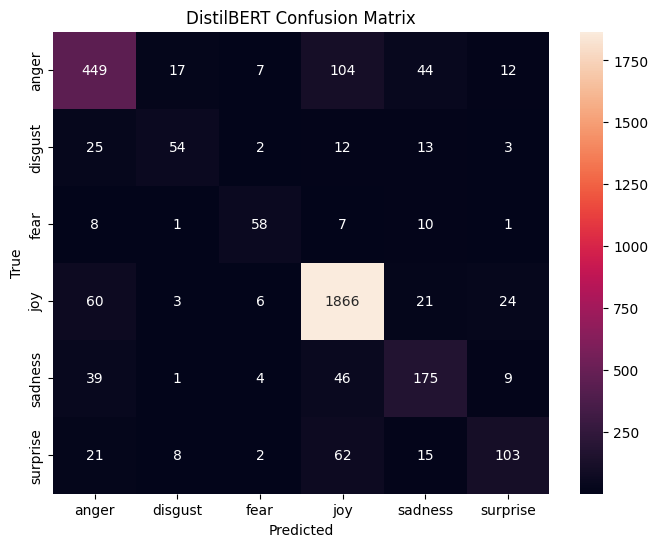

In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DistilBERT Confusion Matrix")

plt.show()

In [71]:

results = pd.DataFrame({
    "Model": [
        "LSTM",
        "GRU",
        "BiLSTM + Attention",
        "DistilBERT"
    ],

    "Accuracy": [
        0.7564,
        0.7609,
        0.7224,
        0.8217
    ],

    "Macro F1": [
        0.6048,
        0.6092,
        0.3705,
        0.6852
    ]
})

results

,Model,Accuracy,Macro F1
0,LSTM,0.7564,0.6048
1,GRU,0.7609,0.6092
2,BiLSTM + Attention,0.7224,0.3705
3,DistilBERT,0.8217,0.6852


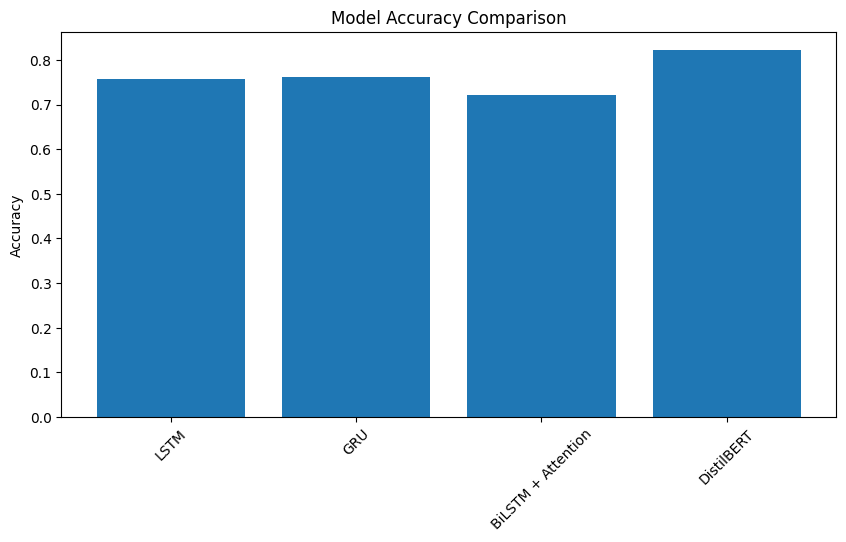

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

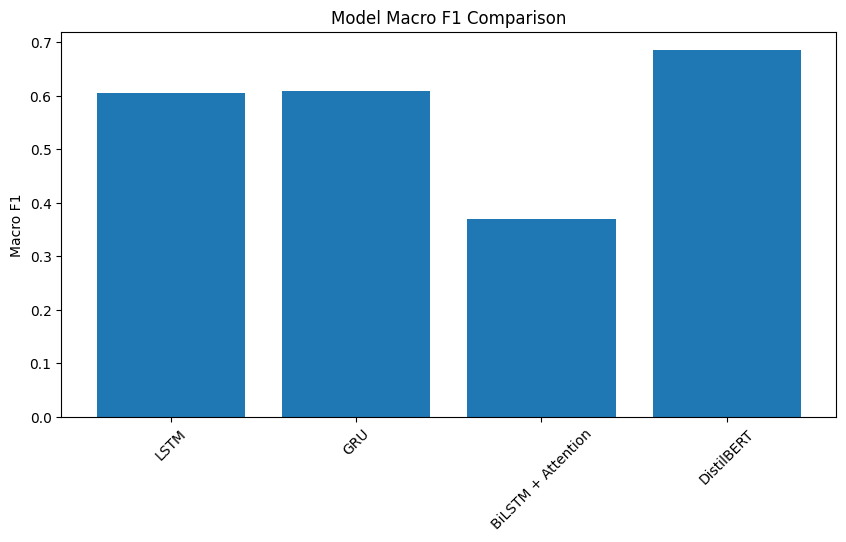

In [73]:
plt.figure(figsize=(10,5))

plt.bar(
    results["Model"],
    results["Macro F1"]
)

plt.xticks(rotation=45)

plt.ylabel("Macro F1")

plt.title("Model Macro F1 Comparison")

plt.show()

In [74]:
model_path = "./emotion_distilbert"

trainer.save_model(model_path)

tokenizer.save_pretrained(model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./emotion_distilbert/tokenizer_config.json',
 './emotion_distilbert/tokenizer.json')

In [75]:
import pickle

with open("label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder,f)

In [76]:
!zip -r emotion_distilbert.zip emotion_distilbert

  adding: emotion_distilbert/ (stored 0%)
  adding: emotion_distilbert/config.json (deflated 54%)
  adding: emotion_distilbert/model.safetensors (deflated 8%)
  adding: emotion_distilbert/tokenizer_config.json (deflated 43%)
  adding: emotion_distilbert/tokenizer.json (deflated 71%)
  adding: emotion_distilbert/training_args.bin (deflated 54%)


In [77]:
from google.colab import files

files.download("emotion_distilbert.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>